# CNN tutorial: 1D grid-to-grid prediction with a single convolutional kernel

This notebook follows the CNN recipe card on a very small supervised task.

## Goal
- Train the **simplest CNN**: one convolutional layer with a single learnable kernel
- Check whether it can predict the **tree center map**
- Inspect the **learned kernel**

## Mini recipe card

### Data
- Each sample is a **vertical 1D grid** stored as an image-like tensor of shape `[1, N, 1]`
- Input: one local **tree** pattern inside background noise
- Target: a **same-size binary response map** with `1` at the tree center

### NN model
- Use the simplest CNN possible:
  - `Conv2d(in_channels=1, out_channels=1, kernel_size=(k,1), padding=(k//2,0))`
- No hidden stack, just **one learnable kernel + one bias**

### Training
- Loss: `BCEWithLogitsLoss`
- Optimizer: `Adam`
- Evaluate on validation and test sets
- At the end, visualize:
  - predictions
  - learned kernel weights

## load libraries

In [122]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

torch.manual_seed(10)
random.seed(10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2) load the dataset

We store the dataset under:

- `./data/tree1d_vertical/processed/train.pt`
- `./data/tree1d_vertical/processed/test.pt`
- `./data/tree1d_vertical/processed/meta.pt`

Each input is a **vertical strip** with shape `[1, N, 1]`.

**Note 1:** on Shape convention for Grids in pytorch

In PyTorch, grid-structured data is usually stored as

$$
[C,\; n_1,\; \ldots,\; n_d]
$$

where:
- $C$ is the number of channels
- $d$ is the grid dimension
- $n_1,\ldots,n_d$ are the grid sizes

Examples:
- **1D grid:** $[C,\; N]$
- **2D grid:** $[C,\; H,\; W]$

In this notebook, each sample is stored as

$$
[1,\; N,\; 1]
$$

This means:
- **1 channel** (grayscale)
- **height = $N$** positions
- **width = 1** column

So our 1D signal is represented as a very narrow vertical image.  
This keeps the data in a grid format and lets us use a standard CNN layer naturally.

In [123]:
class Tree1DImageDiskDataset(Dataset):
    """
    Loads the saved dataset from disk.

    Expected folder structure:
        ./data/tree1d_vertical_v1/processed/train.pt
        ./data/tree1d_vertical_v1/processed/test.pt
        ./data/tree1d_vertical_v1/processed/meta.pt
    """

    def __init__(
        self,
        root: str = "./data",
        dataset_name: str = "tree1d_vertical_v1",
        train: bool = True,
    ):
        super().__init__()

        self.root = Path(root)
        self.dataset_name = dataset_name
        self.dataset_dir = self.root / self.dataset_name
        self.processed_dir = self.dataset_dir / "processed"

        train_path = self.processed_dir / "train.pt"
        test_path = self.processed_dir / "test.pt"
        meta_path = self.processed_dir / "meta.pt"

        if not train_path.exists() or not test_path.exists() or not meta_path.exists():
            raise FileNotFoundError(
                f"Could not find dataset files in:\n{self.processed_dir.resolve()}\n\n"
                f"Make sure you already created and saved the dataset."
            )

        split_path = train_path if train else test_path
        self.data = torch.load(split_path)
        self.meta = torch.load(meta_path)
        self.train = train

    def __len__(self):
        return self.data["x_img"].shape[0]

    def __getitem__(self, idx):
        return {
            "x_img": self.data["x_img"][idx],                    # [1, N, 1]
            "target_map_img": self.data["target_map_img"][idx], # [1, N, 1]
            "target_map": self.data["target_map"][idx],         # [N]
            "center_index": self.data["center_index"][idx],     # scalar
        }


In [124]:
train_full = Tree1DImageDiskDataset(root="./data", dataset_name="tree1d_vertical", train=True)
test_dataset = Tree1DImageDiskDataset(root="./data", dataset_name="tree1d_vertical", train=False)

## 3) Setting up the DataLoader

**Note 2:**  When samples are loaded in batches, PyTorch adds a batch dimension in front:

$$
X_{\text{batch}} \in \mathbb{R}^{B \times C \times H \times W}
$$

So with batch size $B=128$ and $N=50$, we get

$$
X_{\text{batch}} \in \mathbb{R}^{128 \times 1 \times 50 \times 1}
$$

In [125]:
n_train = int(0.8 * len(train_full))
n_val = len(train_full) - n_train

train_dataset, val_dataset = random_split(
    train_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train:", len(train_dataset))
print("val  :", len(val_dataset))
print("test :", len(test_dataset))

batch = next(iter(train_loader))
print("x_img shape         :", batch["x_img"].shape)
print("target_map_img shape:", batch["target_map_img"].shape)
print("center_index shape  :", batch["center_index"].shape)

train: 1600
val  : 400
test : 400
x_img shape         : torch.Size([128, 1, 50, 1])
target_map_img shape: torch.Size([128, 1, 50, 1])
center_index shape  : torch.Size([128])


## 4) Define the simplest CNN

We use a **single convolutional layer** with:
- one input channel
- one output channel
- one learnable kernel of size `(k,1)`

The output is a **logit map** with the same spatial size as the input.

**Note 3** Important terminology for this notebook

- **Conv filter =** $\phi$  
  just the kernel weights $w$, i.e. the learnable local pattern

- **Conv layer**  
  strictly:
  $$
  \phi \star x + b
  $$
  this is what `nn.Conv2d` gives us

- **Nonlinearity**  
  a separate layer, e.g. `nn.ReLU`

- **Conv block**  
  conv layer + nonlinearity

- **CNN**  
  a stack of conv blocks

In [126]:
# --------------------------------------------
# Build the simplest possible CNN in PyTorch
# --------------------------------------------
# Here we will start with the simplest case: one conv layer with a single learnable kernel
# Why Conv2d and not Conv1d? Because our data is stored as a vertical image strip with shape [B, 1, N, 1],
# so it is natural to treat it as a 2D grid with width = 1.

class SingleKernelCNN(nn.Module):
    def __init__(self, kernel_size: int = 9):
        super().__init__()

        # Save kernel size so we can use it later in forward()
        self.kernel_size = kernel_size

        
        # One convolution layer:  output = φ * x + b
        self.conv1 = nn.Conv2d(
            in_channels=1,  # in_channels=1  -> grayscale input
            out_channels=1,  # out_channels=1 -> one output feature map
            kernel_size=(kernel_size, 1),  # kernel_size=(kernel_size, 1) -> a vertical kernel
            stride=1,  # stride=1 -> move one position at a time
            padding=(kernel_size // 2, 0),  # padding=0 -> we will pad manually in forward()
            bias=True, # bias=True -> also learn one bias term
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        # x has shape [(B= batch size), (1= number of channels), (N=height), (1=width)]
        
        # Apply the convolution layer:
        #   z = φ * x + b
        x = self.conv1(x)  # shape: [B, 1, N, 1]
        x = self.relu(x)

        return x


# --------------------------------------------
# Create the model
# --------------------------------------------
kernel_size = 7
model = SingleKernelCNN(kernel_size=kernel_size).to(device)

# Print the model structure
print(model)

# Inspect learnable parameter shapes
print("conv weight shape:", tuple(model.conv1.weight.shape))
print("conv bias shape  :", tuple(model.conv1.bias.shape))

SingleKernelCNN(
  (conv1): Conv2d(1, 1, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0))
  (relu): ReLU()
)
conv weight shape: (1, 1, 7, 1)
conv bias shape  : (1,)


## 5) Loss, metric, and train / evaluation functions

Because the target is a **binary response map**, we use `BCEWithLogitsLoss`.

We also track a simple localization metric:
- take the argmax of the predicted probability map
- compare it to the true center index

In [127]:
def compute_center_accuracy(logits, center_index):
    probs = torch.sigmoid(logits)
    pred_idx = probs.squeeze(1).squeeze(-1).argmax(dim=1)
    acc = (pred_idx == center_index).float().mean().item()
    return acc


length = train_full.meta["length"]
pos_weight = torch.tensor([length - 1], device=device, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-2)

## 6-Define the train and test functions

In [128]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["x_img"].to(device)
        y = batch["target_map_img"].to(device)
        centers = batch["center_index"].to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += compute_center_accuracy(logits.detach(), centers)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["x_img"].to(device)
        y = batch["target_map_img"].to(device)
        centers = batch["center_index"].to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += compute_center_accuracy(logits, centers)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

## 7) Train the model

In [129]:
num_epochs = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

model.load_state_dict(best_state)
print("\nLoaded best model based on validation loss.")

epoch 01 | train_loss=1.0939 | val_loss=0.9972 | train_acc=0.0000 | val_acc=0.0000
epoch 02 | train_loss=0.9788 | val_loss=0.9554 | train_acc=0.0000 | val_acc=0.0020
epoch 03 | train_loss=0.9415 | val_loss=0.9288 | train_acc=0.2151 | val_acc=0.6758
epoch 04 | train_loss=0.9199 | val_loss=0.9099 | train_acc=0.8528 | val_acc=0.9746
epoch 05 | train_loss=0.9035 | val_loss=0.8964 | train_acc=0.9874 | val_acc=0.9922
epoch 06 | train_loss=0.8913 | val_loss=0.8846 | train_acc=0.9976 | val_acc=1.0000
epoch 07 | train_loss=0.8796 | val_loss=0.8731 | train_acc=0.9994 | val_acc=1.0000
epoch 08 | train_loss=0.8684 | val_loss=0.8620 | train_acc=0.9994 | val_acc=1.0000
epoch 09 | train_loss=0.8576 | val_loss=0.8516 | train_acc=1.0000 | val_acc=1.0000
epoch 10 | train_loss=0.8475 | val_loss=0.8418 | train_acc=1.0000 | val_acc=1.0000
epoch 11 | train_loss=0.8383 | val_loss=0.8326 | train_acc=1.0000 | val_acc=1.0000
epoch 12 | train_loss=0.8293 | val_loss=0.8241 | train_acc=1.0000 | val_acc=1.0000
epoc

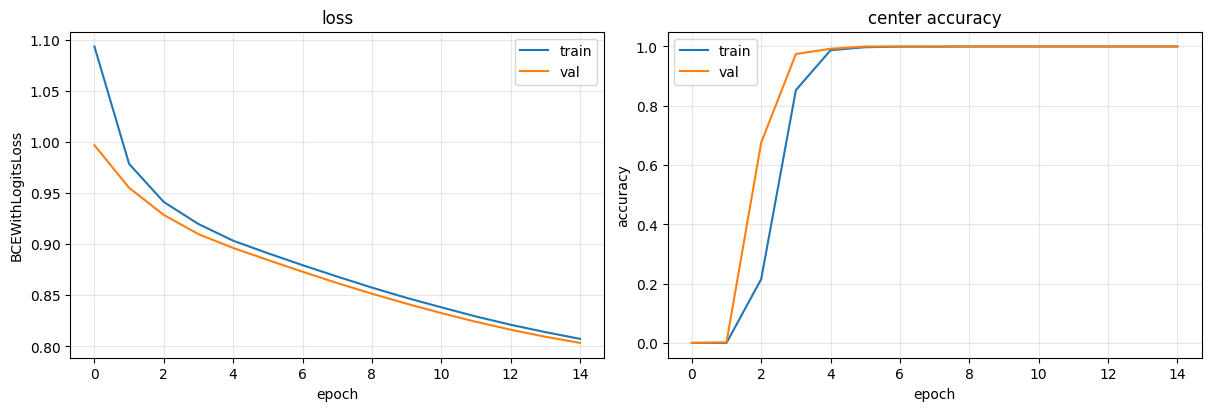

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("center accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

## 5) Test performance

In [131]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"test_loss = {test_loss:.4f}")
print(f"test_center_accuracy = {test_acc:.4f}")

test_loss = 0.8046
test_center_accuracy = 1.0000


## 6) Visualize predictions

We show:
- input grid
- true target map
- predicted probability map

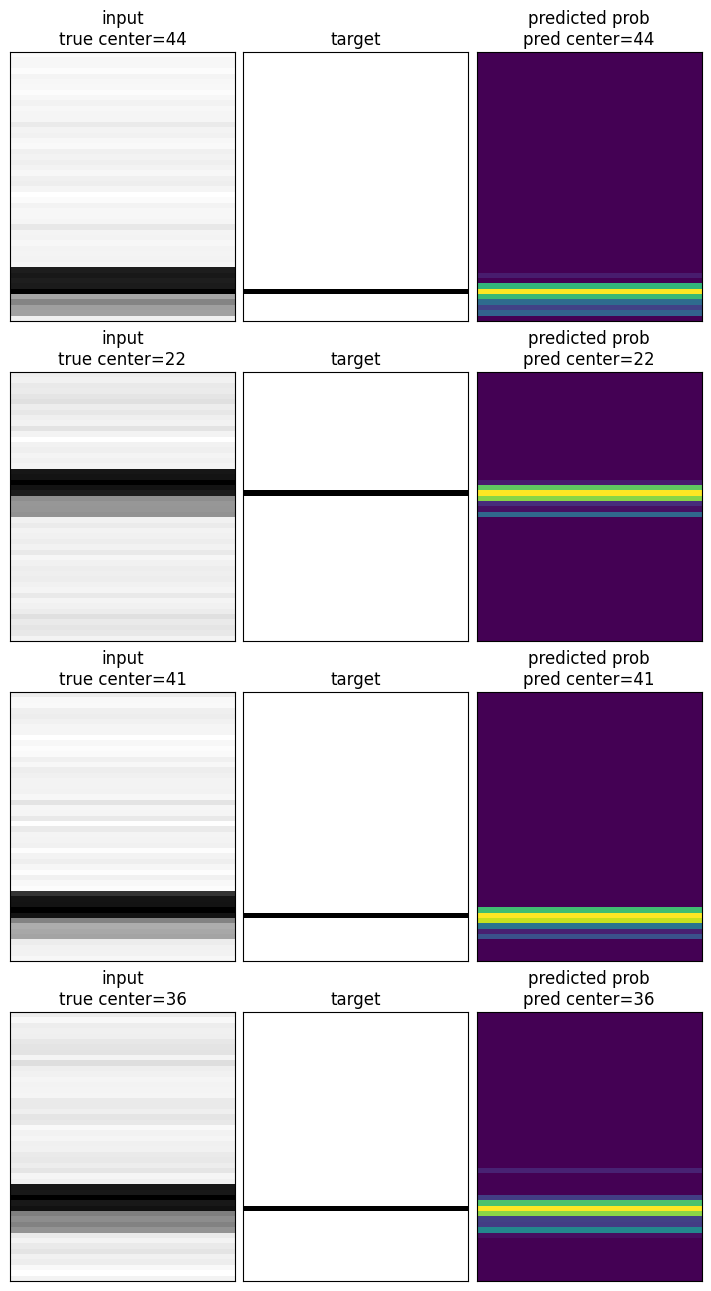

In [132]:
@torch.no_grad()
def show_predictions(model, dataset, indices):
    model.eval()

    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(7, 3.2 * n), constrained_layout=True)

    if n == 1:
        axes = axes.reshape(1, 3)

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        x = sample["x_img"].unsqueeze(0).to(device)
        y_true = sample["target_map_img"][0].numpy()
        center = int(sample["center_index"])

        logits = model(x)
        probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()  # [N, 1]
        pred_center = int(torch.sigmoid(logits)[0, 0, :, 0].argmax().item())

        x_img = sample["x_img"][0].numpy()

        axes[row, 0].imshow(x_img, aspect="auto", interpolation="nearest", cmap="Greys", origin="upper")
        axes[row, 0].set_title(f"input\ntrue center={center}")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        axes[row, 1].imshow(y_true, aspect="auto", interpolation="nearest", cmap="Greys", origin="upper", vmin=0, vmax=1)
        axes[row, 1].set_title("target")
        axes[row, 1].set_xticks([])
        axes[row, 1].set_yticks([])

        axes[row, 2].imshow(probs, aspect="auto", interpolation="nearest", cmap="viridis", origin="upper")
        axes[row, 2].set_title(f"predicted prob\npred center={pred_center}")
        axes[row, 2].set_xticks([])
        axes[row, 2].set_yticks([])

    plt.show()


show_predictions(model, test_dataset, indices=[0, 1, 2, 3])

## 7) (bonus) Visualize the learned kernel

Because the model has only **one convolutional layer** and **one output channel**, the learned filter is easy to inspect directly.)Visualize the learned kernel

Because the model has only **one convolutional layer** and **one output channel**, the learned filter is easy to inspect directly.

In [133]:
weight = model.conv1.weight.detach().cpu().squeeze().numpy()  # [kernel_size]
bias = model.conv1.bias.detach().cpu().item()

print("learned bias:", round(float(bias), 4))
print("learned kernel weights:", weight)

learned bias: -1.8407
learned kernel weights: [ 1.1511967   0.91784984  1.0932131   2.0627878  -2.388917   -0.62467146
  1.6124734 ]


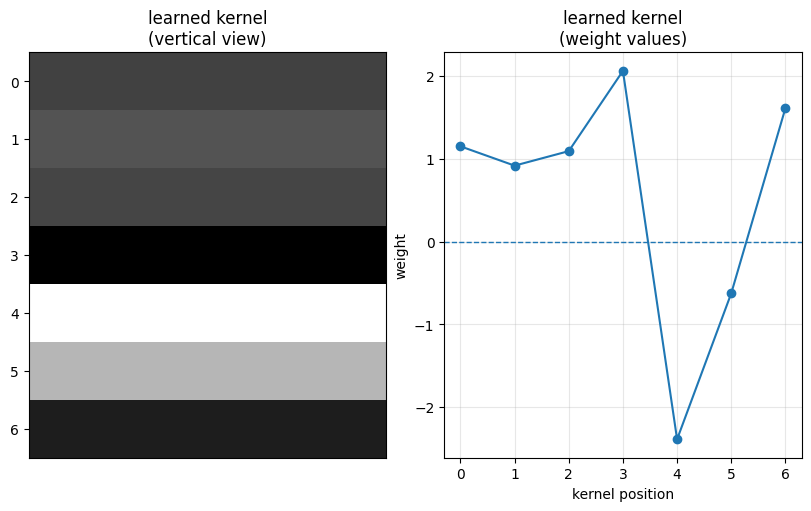

In [134]:
weight = model.conv1.weight.detach().cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

axes[0].imshow(weight.reshape(-1, 1), aspect="auto", interpolation="nearest", cmap="Greys")
axes[0].set_title("learned kernel\n(vertical view)")
axes[0].set_xticks([])
axes[0].set_yticks(range(len(weight)))

axes[1].plot(range(len(weight)), weight, marker="o")
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_title("learned kernel\n(weight values)")
axes[1].set_xlabel("kernel position")
axes[1].set_ylabel("weight")
axes[1].grid(alpha=0.3)

plt.show()

#### What to notice

- The model is extremely small: just **one kernel + one bias**
- Even this simple CNN can learn a local pattern detector
- The learned kernel should reflect the rough structure of the synthetic tree pattern